# Lab 1: Analysing Student Performance

https://archive.ics.uci.edu/dataset/320/student+performance <br>
The Student Performance dataset was found on the UC Irvine Machine Learning Repository. The dataset contains data from two different Portuguese schools. The dataset aims to understand student performance by analyzing factors that could affect a student's success, such as family life, absences, social life, and time spent studying.

# Imports

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Print Portion of Data

In [11]:
studentInfo = pd.read_csv('student-mat.csv', sep = ';')
pd.set_option('display.max_columns', None)

In [59]:
studentInfo.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


# Bar Graph

This bar graph analyzes if there is a correlation between the time a student spends studying and the number of times a student fails a class. The graph shows comparisons between the two different schools. The results show that the students at the GP school spend more time studying and experience fewer failures compared to the MS school.

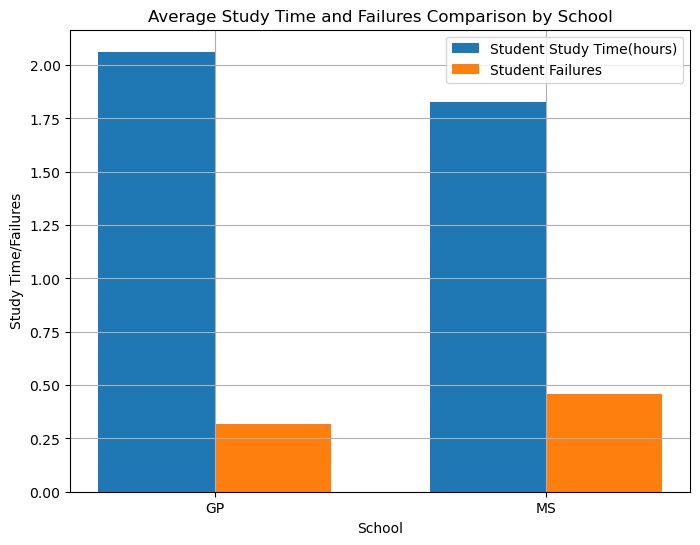

In [100]:
avgStudyTime = studentInfo.groupby('school')['studytime'].mean()
avgFailures = studentInfo.groupby('school')['failures'].mean()
school = avgStudyTime.index.tolist()
x = np.arange(len(school))
width = 0.35

fig = plt.figure(figsize = (8,6))
plt.bar(x - width/2, avgStudyTime, width, label = 'Student Study Time(hours)')
plt.bar(x + width/2, avgFailures, width, label = 'Student Failures')

plt.xticks(x, school)
plt.xlabel('School')
plt.ylabel('Study Time/Failures')
plt.title('Average Study Time and Failures Comparison by School')
plt.legend()
plt.grid()
plt.show()
fig.savefig('RubyStudyBar.png')

# Line Graph

This line graph analyzes the possibility of correlation between age and failure rates. The results show, on average, older students fail more classes.

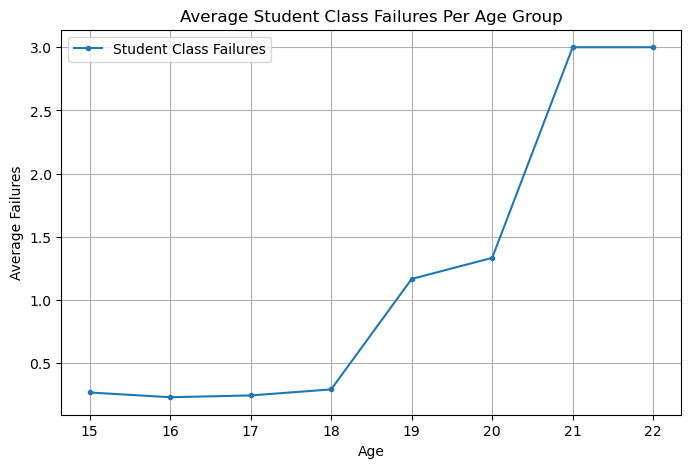

In [102]:
ageFailGroups = studentInfo.groupby('age')['failures'].mean()
fig = plt.figure(figsize = (8, 5))
plt.plot(ageFailGroups.index, ageFailGroups.values, marker = '.', linestyle = '-', label = 'Student Class Failures')
plt.title('Average Student Class Failures Per Age Group')
plt.xlabel('Age')
plt.ylabel('Average Failures')
plt.legend()
plt.grid()
plt.show()
fig.savefig('RubyFailureLine.png')

# Pie Chart

This pie chart visualizes the education levels for parents of the students. The results show very little parents have no education.

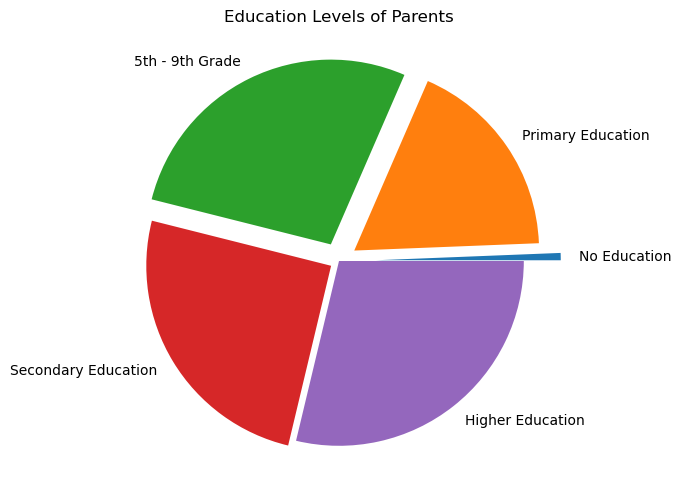

In [104]:
momEdu = studentInfo['Medu'].value_counts().sort_index()
dadEdu = studentInfo['Fedu'].value_counts().sort_index()
comb = momEdu + dadEdu
labels = ['No Education', 'Primary Education', '5th - 9th Grade', 'Secondary Education', 'Higher Education']
fig = plt.figure(figsize = (8, 6))
explode = [0.2, 0.1, 0.1, 0.05, 0]
plt.pie(comb, labels = labels, explode = explode)
plt.title('Education Levels of Parents')
plt.show()
fig.savefig('RubyParentEduPie.png')

# Boxplot

This boxplot visualizes the number of absences from students each school has. The results show GP has more absences.

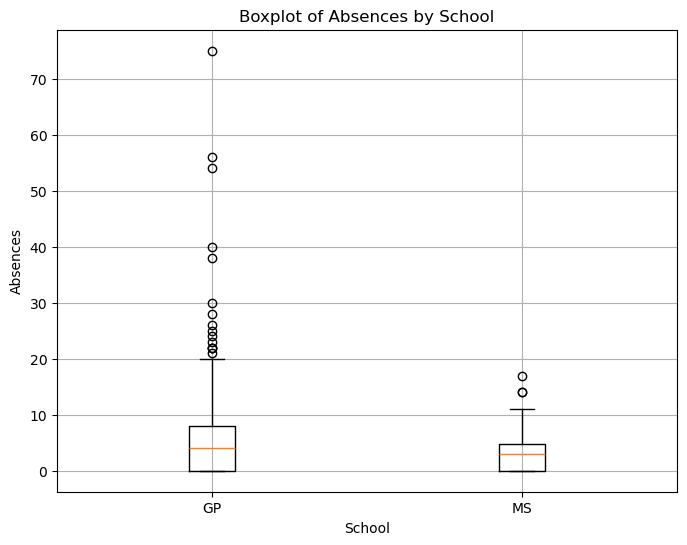

In [108]:
school = studentInfo['school'].unique()
data = [studentInfo[studentInfo['school'] == sc]['absences'] for sc in school]
fig = plt.figure(figsize = (8, 6))
plt.boxplot(data, tick_labels = school)
plt.title('Boxplot of Absences by School')
plt.xlabel('School')
plt.ylabel('Absences')
plt.grid()
plt.show()
fig.savefig('RubyAbsencesBox.png')